In [1]:
#Load stock data
import pandas as pd

stock_df = pd.read_csv("../data/raw/NVDA.csv")
stock_df.isnull().sum() #Check for and handle missing values
stock_df.dropna(inplace=True)
stock_df.dtypes
stock_df.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,0.199652,0.201027,0.184294,0.184982,497124000
1,2009-01-05,0.203319,0.207904,0.195984,0.197360,705736000
2,2009-01-06,0.210196,0.216156,0.204695,0.209279,657904000
3,2009-01-07,0.197589,0.205382,0.190483,0.205382,870096000
4,2009-01-08,0.192546,0.195067,0.180626,0.195067,1014496000


In [2]:
#Convert Date
stock_df["Date"] = pd.to_datetime(stock_df["Date"])
stock_df = stock_df.sort_values("Date")
stock_df.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,0.199652,0.201027,0.184294,0.184982,497124000
1,2009-01-05,0.203319,0.207904,0.195984,0.197360,705736000
2,2009-01-06,0.210196,0.216156,0.204695,0.209279,657904000
3,2009-01-07,0.197589,0.205382,0.190483,0.205382,870096000
4,2009-01-08,0.192546,0.195067,0.180626,0.195067,1014496000


In [3]:
#Set price column
price = stock_df["Close"]
print(price.head())

0    0.199652
1    0.203319
2    0.210196
3    0.197589
4    0.192546
Name: Close, dtype: float64


In [4]:
#Moving Averages (SMA & EMA)
from ta.trend import SMAIndicator, EMAIndicator

stock_df["SMA_20"] = SMAIndicator(price, window=20).sma_indicator()
stock_df["EMA_20"] = EMAIndicator(price, window=20).ema_indicator()
stock_df.head()

,Date,Close,High,Low,Open,Volume,SMA_20,EMA_20
0,2009-01-02,0.199652,0.201027,0.184294,0.184982,497124000,NaN,NaN
1,2009-01-05,0.203319,0.207904,0.195984,0.197360,705736000,NaN,NaN
2,2009-01-06,0.210196,0.216156,0.204695,0.209279,657904000,NaN,NaN
3,2009-01-07,0.197589,0.205382,0.190483,0.205382,870096000,NaN,NaN
4,2009-01-08,0.192546,0.195067,0.180626,0.195067,1014496000,NaN,NaN


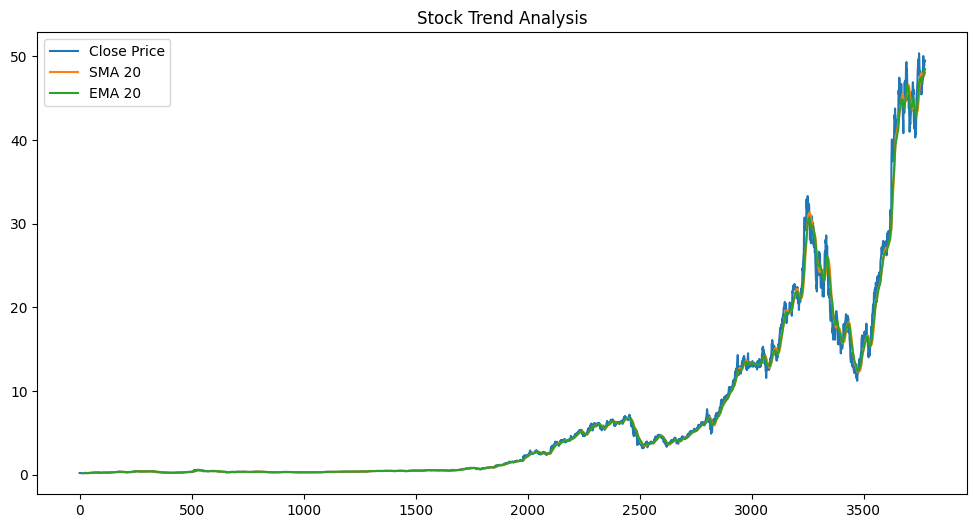

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(stock_df["Close"], label="Close Price")
plt.plot(stock_df["SMA_20"], label="SMA 20")
plt.plot(stock_df["EMA_20"], label="EMA 20")

plt.legend()
plt.title("Stock Trend Analysis")
plt.show()

In [6]:
#RSI (momentum indicator)
from ta.momentum import RSIIndicator

stock_df["RSI"] = RSIIndicator(price, window=14).rsi()
stock_df.head()

,Date,Close,High,Low,Open,Volume,SMA_20,EMA_20,RSI
0,2009-01-02,0.199652,0.201027,0.184294,0.184982,497124000,NaN,NaN,NaN
1,2009-01-05,0.203319,0.207904,0.195984,0.197360,705736000,NaN,NaN,NaN
2,2009-01-06,0.210196,0.216156,0.204695,0.209279,657904000,NaN,NaN,NaN
3,2009-01-07,0.197589,0.205382,0.190483,0.205382,870096000,NaN,NaN,NaN
4,2009-01-08,0.192546,0.195067,0.180626,0.195067,1014496000,NaN,NaN,NaN


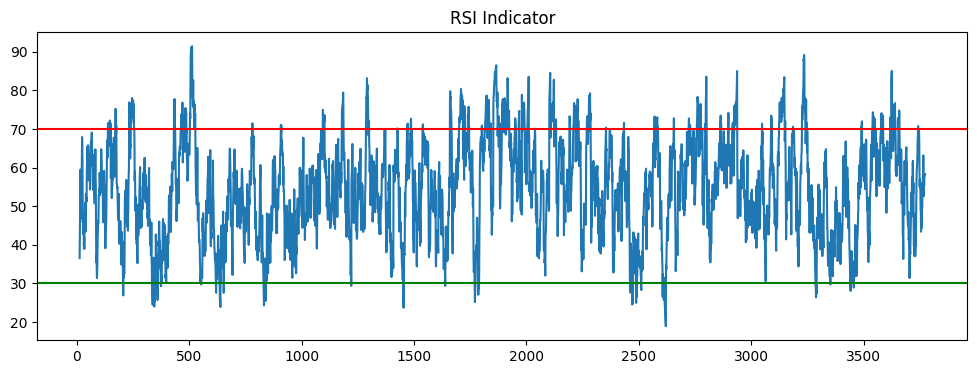

In [7]:
plt.figure(figsize=(12,4))
plt.plot(stock_df["RSI"])
plt.axhline(70, color='red')
plt.axhline(30, color='green')
plt.title("RSI Indicator")
plt.show()

In [8]:
#MACD (trend signal)
from ta.trend import MACD

macd = MACD(price)

stock_df["MACD"] = macd.macd()
stock_df["MACD_signal"] = macd.macd_signal()
stock_df.head()

,Date,Close,High,Low,Open,Volume,SMA_20,EMA_20,RSI,MACD,MACD_signal
0,2009-01-02,0.199652,0.201027,0.184294,0.184982,497124000,NaN,NaN,NaN,NaN,NaN
1,2009-01-05,0.203319,0.207904,0.195984,0.197360,705736000,NaN,NaN,NaN,NaN,NaN
2,2009-01-06,0.210196,0.216156,0.204695,0.209279,657904000,NaN,NaN,NaN,NaN,NaN
3,2009-01-07,0.197589,0.205382,0.190483,0.205382,870096000,NaN,NaN,NaN,NaN,NaN
4,2009-01-08,0.192546,0.195067,0.180626,0.195067,1014496000,NaN,NaN,NaN,NaN,NaN


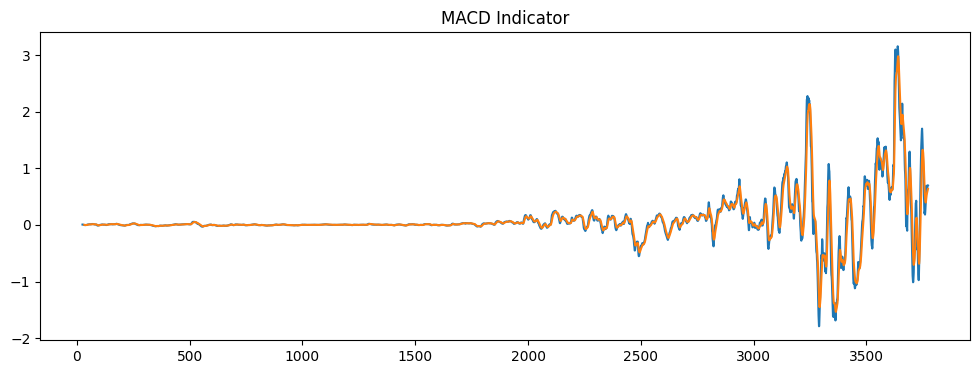

In [9]:
#MACD
plt.figure(figsize=(12,4))
plt.plot(stock_df["MACD"], label="MACD")
plt.plot(stock_df["MACD_signal"], label="Signal Line")
plt.title("MACD Indicator")
plt.show()

Volatility: 0.028917294429857777
Average Daily Return: 0.0018769341563542393
Sharpe Ratio: 0.06353469966314326


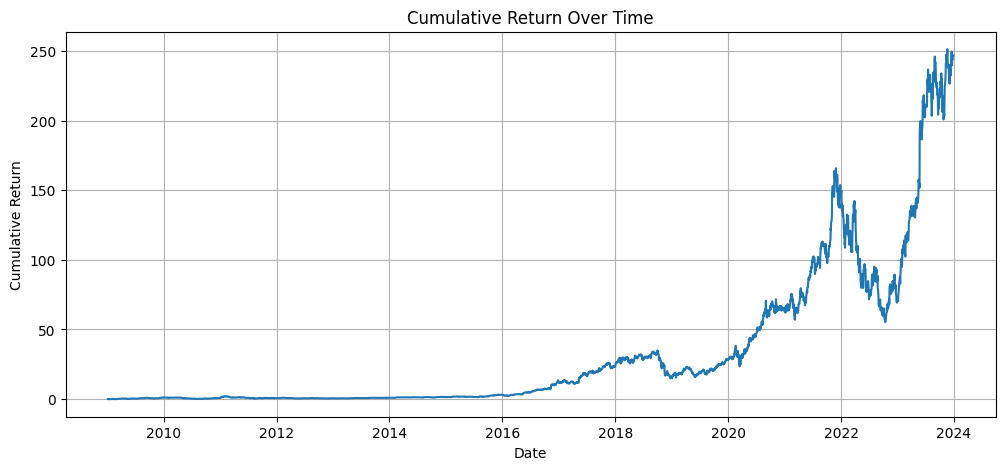

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

stock_df["Daily_Return"] = stock_df["Close"].pct_change()

volatility = stock_df["Daily_Return"].std()
avg_return = stock_df["Daily_Return"].mean()

stock_df["Cumulative_Return"] = (1 + stock_df["Daily_Return"]).cumprod() - 1

risk_free_rate = 0.01 / 252

sharpe_ratio = (
    (stock_df["Daily_Return"].mean() - risk_free_rate)
    / stock_df["Daily_Return"].std()
)

print("Volatility:", volatility)
print("Average Daily Return:", avg_return)
print("Sharpe Ratio:", sharpe_ratio)